In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import re

# HarrisPartI

In [40]:

harris1 = pd.read_csv("HarrisPartI.csv")

harris1.head()




,ID,Name,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z
0,NGC 104,47 Tuc,00:24:05.67,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1
1,NGC 288,NaN,00:52:45.24,-26:34:57.4,152.30,-89.38,8.9,12.0,-0.1,0.0,-8.9
2,NGC 362,NaN,01:03:14.26,-70:50:55.6,301.53,-46.25,8.6,9.4,3.1,-5.1,-6.2
3,Whiting 1,NaN,02:02:57,-03:15:10,161.22,-60.76,30.1,34.5,-13.9,4.7,-26.3
4,NGC 1261,NaN,03:12:16.21,-55:12:58.4,270.54,-52.12,16.3,18.1,0.1,-10.0,-12.9


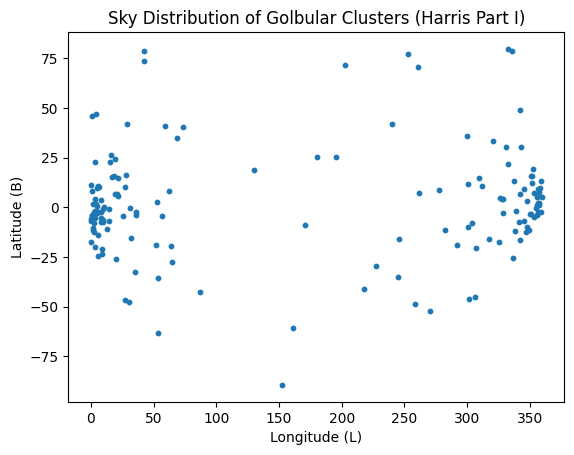

In [41]:
plt.scatter(harris1['L'], harris1['B'], s=10)
plt.xlabel("Longitude (L)")
plt.ylabel("Latitude (B)")
plt.title("Sky Distribution of Golbular Clusters (Harris Part I)")
plt.show()




# HarrisPartIII

In [42]:
harris3 = pd.read_csv("HarrisPartIII.csv")
harris3.head()

,ID,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th
0,NGC 104,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55
1,NGC 288,-45.4,0.2,-51.9,2.9,0.3,0.99,1.35,2.23,20.05,1.78,8.99,9.32
2,NGC 362,223.5,0.5,214.0,6.4,0.3,1.76,0.18,0.82,14.80,4.74,7.76,8.93
3,Whiting 1,-130.6,1.8,-138.1,NaN,NaN,0.55,0.25,0.22,NaN,NaN,NaN,7.93
4,NGC 1261,68.2,4.6,54.9,NaN,NaN,1.16,0.35,0.68,17.73,2.99,8.59,9.12


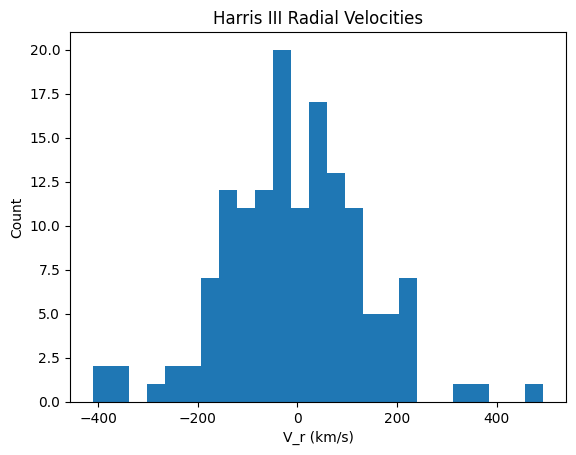

In [43]:
# histogram of radial velocities of harris3. 
plt.hist(harris3["v_r"].dropna(), bins = 25)
plt.xlabel("V_r (km/s)")
plt.ylabel("Count")
plt.title("Harris III Radial Velocities")
plt.show()

# VandenBerg


In [44]:
vBerg = pd.read_csv("vandenBerg_table2.csv")
vBerg.head()

,#NGC,Name,FeH,Age,Age_err,Method,Figs,Range,HBtype,R_G,M_V,v_e0,log_sigma_0
0,104,47Tuc,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,-9.42,54.8,5.061
1,288,XXXX,-1.32,11.50,0.38,H,24,NaN,0.98,12.0,-6.75,10.9,2.953
2,362,XXXX,-1.30,10.75,0.25,V,13,10.75–11.00,-0.87,9.4,-8.43,44.4,4.938
3,1261,XXXX,-1.27,10.75,0.25,V,13,10.75–11.25,-0.71,18.1,-7.80,23.6,3.913
4,1851,XXXX,-1.18,11.00,0.25,V,13,10.75–11.25,-0.32,16.6,-8.33,47.6,5.136


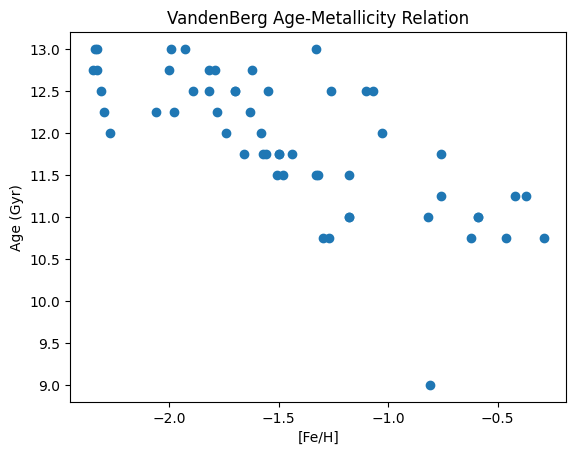

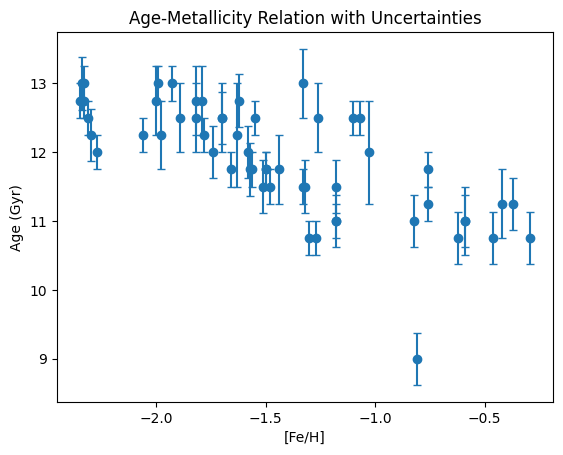

In [45]:
# Vandgberg Age Metallicity Relation
plt.scatter(vBerg["FeH"], vBerg["Age"])
plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("VandenBerg Age-Metallicity Relation")
plt.show()

# plot with error bars. 
plt.errorbar(vBerg["FeH"], vBerg["Age"], yerr=vBerg["Age_err"], fmt="o", capsize=3)
plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("Age-Metallicity Relation with Uncertainties")
plt.show()


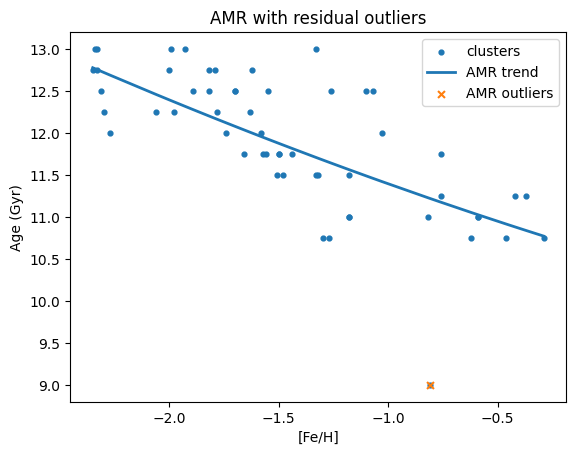

,Name,FeH,Age,Age_trend,Age_resid
53,Pal12,-0.81,9.0,11.220829,-2.220829


In [46]:
# vdb must already be loaded with columns: "FeH", "Age", "Age_err" (Age_err optional)
v = vBerg.dropna(subset=["FeH","Age"]).copy()

# polynomial AMR trend (2nd order is usually flexible but simple)
coef = np.polyfit(v["FeH"], v["Age"], 2, w=None if "Age_err" not in v.columns else 1/np.clip(v["Age_err"].values, 0.1, None))
p = np.poly1d(coef)

v["Age_trend"] = p(v["FeH"])
v["Age_resid"] = v["Age"] - v["Age_trend"]

# Choose residual threshold (tune later)
AMR_RESID_GYR = 1.8
v["amr_outlier"] = (v["Age_resid"].abs() > AMR_RESID_GYR)

# Quick plot with highlight
plt.scatter(v["FeH"], v["Age"], s=12, label="clusters")
plt.plot(np.sort(v["FeH"]), p(np.sort(v["FeH"])), lw=2, label="AMR trend")
plt.scatter(v.loc[v["amr_outlier"], "FeH"], v.loc[v["amr_outlier"], "Age"], s=25, marker="x", label="AMR outliers")
plt.xlabel("[Fe/H]"); plt.ylabel("Age (Gyr)"); plt.title("AMR with residual outliers")
plt.legend(); plt.show()

amr_candidates = v.loc[v["amr_outlier"], ["Name","FeH","Age","Age_trend","Age_resid"]].copy() if "Name" in v.columns else v.loc[v["amr_outlier"], ["FeH","Age","Age_trend","Age_resid"]].copy()
amr_candidates.head()


# Krause21 

In [47]:
krause = pd.read_csv("Krause21.csv")
krause.head()

,Class,Object,AltName,Mstar,rh,C5,Age,FeH
0,GC,NGC104,47Tuc,6.46,7.10,0.92,12.80,-0.76
1,GC,NGC288,Melotte3,0.46,9.80,0.05,12.20,-1.32
2,GC,NGC362,Dunlop62,2.50,3.50,0.72,10.00,-1.26
3,GC,NGC1261,Caldwell87,3.41,5.50,0.62,10.24,-1.08
4,GC,NGC1851,Dunlop508,5.51,3.05,1.81,7.64,-1.13


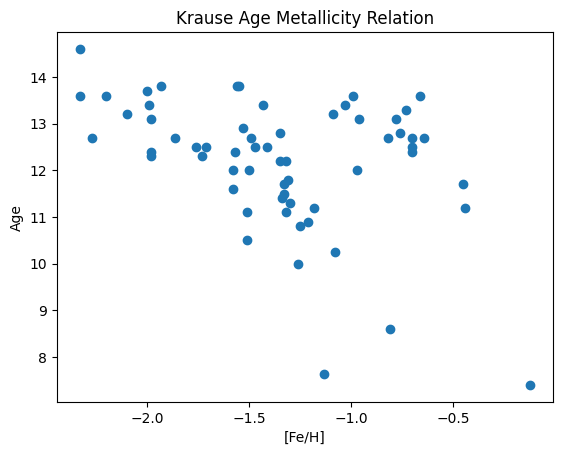

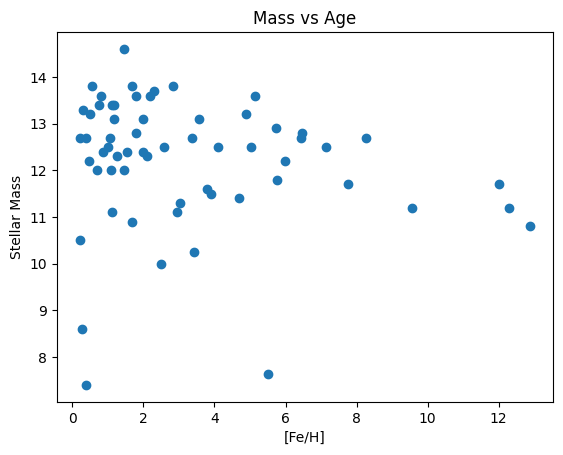

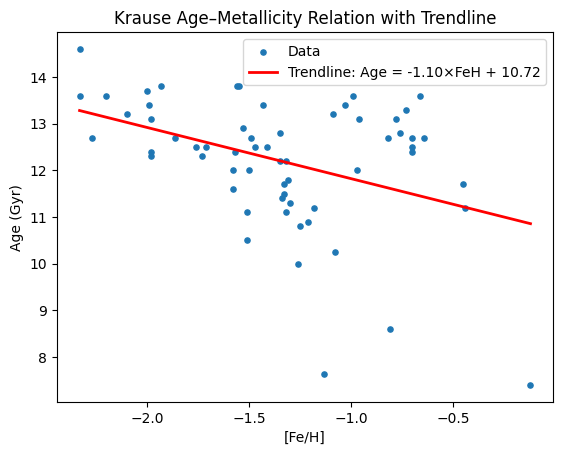

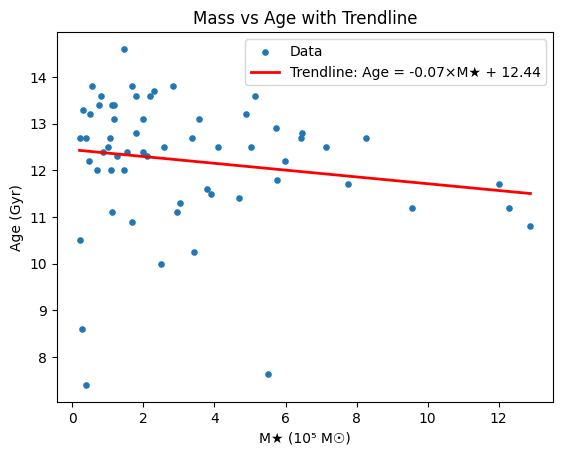

Correlation (Age vs [Fe/H]): r = -0.398


In [48]:
# Age Metallicity Relation 
plt.scatter(krause["FeH"], krause["Age"])
plt.xlabel("[Fe/H]")
plt.ylabel("Age")
plt.title("Krause Age Metallicity Relation")
plt.show()

# Age vs Mstar Stellar Mass
plt.scatter(krause["Mstar"], krause["Age"])
plt.xlabel("[Fe/H]")
plt.ylabel("Stellar Mass")
plt.title("Mass vs Age")
plt.show()

#
### With trendlines
#


# Drop missing values just in case
df = krause.dropna(subset=["FeH", "Age"])

# Scatter
plt.scatter(df["FeH"], df["Age"], s=14, label="Data")

# Fit a simple linear trendline
z = np.polyfit(df["FeH"], df["Age"], 1)
p = np.poly1d(z)

# Plot the trendline
x = np.linspace(df["FeH"].min(), df["FeH"].max(), 100)
plt.plot(x, p(x), color="red", lw=2, label=f"Trendline: Age = {z[0]:.2f}×FeH + {z[1]:.2f}")

plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("Krause Age–Metallicity Relation with Trendline")
plt.legend()
plt.show()

# Drop missing values
df = krause.dropna(subset=["Mstar", "Age"])

plt.scatter(df["Mstar"], df["Age"], s=14, label="Data")

# Fit linear trendline
z = np.polyfit(df["Mstar"], df["Age"], 1)
p = np.poly1d(z)

x = np.linspace(df["Mstar"].min(), df["Mstar"].max(), 100)
plt.plot(x, p(x), color="red", lw=2, label=f"Trendline: Age = {z[0]:.2f}×M★ + {z[1]:.2f}")

plt.xlabel("M★ (10⁵ M☉)")
plt.ylabel("Age (Gyr)")
plt.title("Mass vs Age with Trendline")
plt.legend()
plt.show()

r = np.corrcoef(df["FeH"], df["Age"])[0,1]
print(f"Correlation (Age vs [Fe/H]): r = {r:.3f}")


# VandenBerg + Krause

In [49]:
def make_key(x):
    if pd.isna(x): 
        return None
    s = str(x).strip().upper()
    s = re.sub(r"[^A-Z0-9]", "", s)  # remove spaces/punct
    if s.startswith("NGC"):
        return s
    if s.isdigit():
        return f"NGC{s}"
    return s

#  Normalize column names for Krause only (to lowercase with underscores) 
krause.columns = [c.strip().lower().replace(" ", "_") for c in krause.columns]
print("Krause columns:", krause.columns)  # sanity check

# Build keys 
# VandenBerg: '#NGC' is case-sensitive; keep vBerg if that's your variable name
vBerg["key"] = vBerg["#NGC"].apply(lambda x: f"NGC{int(x)}" if pd.notna(x) and str(x).isdigit() else None)

# Krause: auto-pick an ID column among common variants
id_candidates = ["object", "altname", "name", "cluster", "id", "#ngc", "ngc"]
krause_id = next((c for c in id_candidates if c in krause.columns), None)
if krause_id is None:
    raise KeyError(f"Could not find an ID column in Krause. Saw: {krause.columns}")

krause["key"] = krause[krause_id].apply(make_key)

# Merge with clear suffixes 
vbk = pd.merge(
    vBerg.rename(columns={"FeH": "FeH_vdb", "Age": "Age_vdb"}),
    krause.rename(columns={"feh": "FeH_k", "age": "Age_k"}),  # krause is lowercased now
    on="key", how="inner"
)

vbk.head()

Krause columns: Index(['class', 'object', 'altname', 'mstar', 'rh', 'c5', 'age', 'feh'], dtype='object')


,#NGC,Name,FeH_vdb,Age_vdb,Age_err,Method,Figs,Range,HBtype,R_G,...,log_sigma_0,key,class,object,altname,mstar,rh,c5,Age_k,FeH_k
0,104,47Tuc,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,...,5.061,NGC104,GC,NGC104,47Tuc,6.46,7.10,0.92,12.80,-0.76
1,288,XXXX,-1.32,11.50,0.38,H,24,NaN,0.98,12.0,...,2.953,NGC288,GC,NGC288,Melotte3,0.46,9.80,0.05,12.20,-1.32
2,362,XXXX,-1.30,10.75,0.25,V,13,10.75–11.00,-0.87,9.4,...,4.938,NGC362,GC,NGC362,Dunlop62,2.50,3.50,0.72,10.00,-1.26
3,1261,XXXX,-1.27,10.75,0.25,V,13,10.75–11.25,-0.71,18.1,...,3.913,NGC1261,GC,NGC1261,Caldwell87,3.41,5.50,0.62,10.24,-1.08
4,1851,XXXX,-1.18,11.00,0.25,V,13,10.75–11.25,-0.32,16.6,...,5.136,NGC1851,GC,NGC1851,Dunlop508,5.51,3.05,1.81,7.64,-1.13


In [50]:
vbk.info()
vbk[["FeH_vdb","FeH_k","Age_vdb","Age_k"]].describe()
vbk.isna().mean().sort_values().tail(10)  # where are the gaps?


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   #NGC         51 non-null     object 
 1   Name         51 non-null     object 
 2   FeH_vdb      51 non-null     float64
 3   Age_vdb      51 non-null     float64
 4   Age_err      51 non-null     float64
 5   Method       51 non-null     object 
 6   Figs         51 non-null     object 
 7   Range        32 non-null     object 
 8   HBtype       51 non-null     float64
 9   R_G          51 non-null     float64
 10  M_V          51 non-null     float64
 11  v_e0         51 non-null     float64
 12  log_sigma_0  51 non-null     float64
 13  key          51 non-null     object 
 14  class        51 non-null     object 
 15  object       51 non-null     object 
 16  altname      51 non-null     object 
 17  mstar        51 non-null     float64
 18  rh           51 non-null     float64
 19  c5        

class      0.000000
key        0.000000
object     0.000000
altname    0.000000
Age_k      0.000000
mstar      0.000000
rh         0.000000
c5         0.000000
FeH_k      0.000000
Range      0.372549
dtype: float64

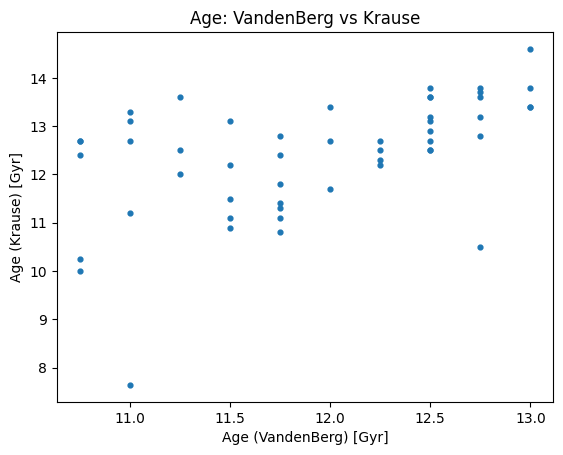

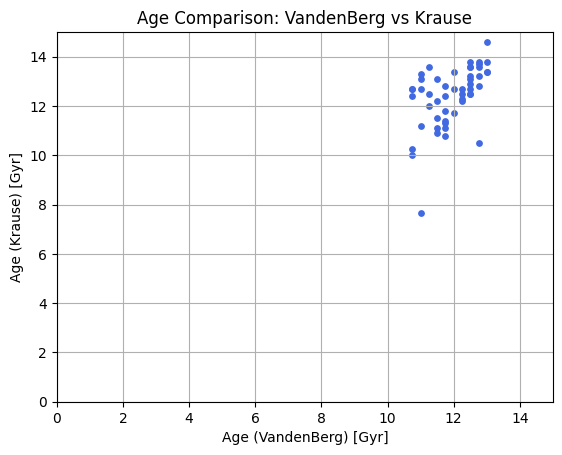

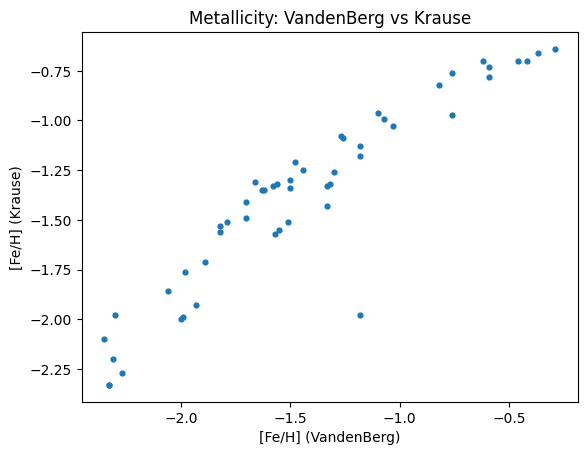

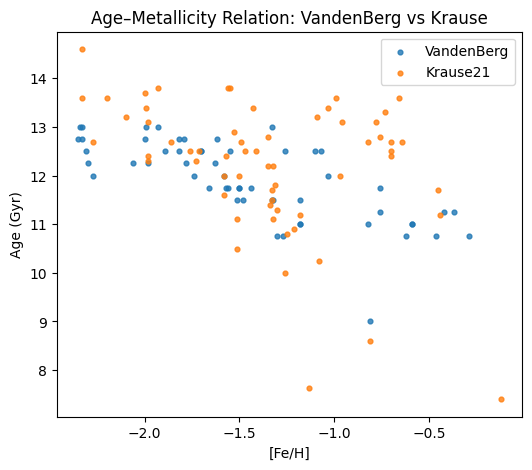

In [51]:
# Age comparison
plt.scatter(vbk["Age_vdb"], vbk["Age_k"], s=12)
plt.xlabel("Age (VandenBerg) [Gyr]"); plt.ylabel("Age (Krause) [Gyr]")
plt.title("Age: VandenBerg vs Krause")
plt.show()

# age comparison but changed scales 
plt.scatter(vbk["Age_vdb"], vbk["Age_k"], s=15, color="royalblue")
plt.xlabel("Age (VandenBerg) [Gyr]")
plt.ylabel("Age (Krause) [Gyr]")
plt.title("Age Comparison: VandenBerg vs Krause")
plt.axis([0, 15, 0, 15])  # consistent axes
plt.grid(True)
plt.show()


# [Fe/H] consistency
plt.scatter(vbk["FeH_vdb"], vbk["FeH_k"], s=12)
plt.xlabel("[Fe/H] (VandenBerg)"); plt.ylabel("[Fe/H] (Krause)")
plt.title("Metallicity: VandenBerg vs Krause")
plt.show()

# COmbine Aged MEtalicity RELation
def pick_col(df, *cands):
    cols = {c.lower(): c for c in df.columns}
    for name in cands:
        if name.lower() in cols:
            return cols[name.lower()]
    raise KeyError(f"None of {cands} found in columns: {list(df.columns)}")

# pick columns (case-insensitive)
feh_vb = pick_col(vBerg, "FeH", "[Fe/H]", "feh")
age_vb = pick_col(vBerg, "Age", "age")
feh_k  = pick_col(krause, "FeH", "feh")
age_k  = pick_col(krause, "Age", "age")

plt.figure(figsize=(6,5))
plt.scatter(vBerg[feh_vb], vBerg[age_vb], s=12, label="VandenBerg", alpha=0.8)
plt.scatter(krause[feh_k],  krause[age_k],  s=12, label="Krause21",  alpha=0.8)
plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("Age–Metallicity Relation: VandenBerg vs Krause")
plt.legend()
plt.show()

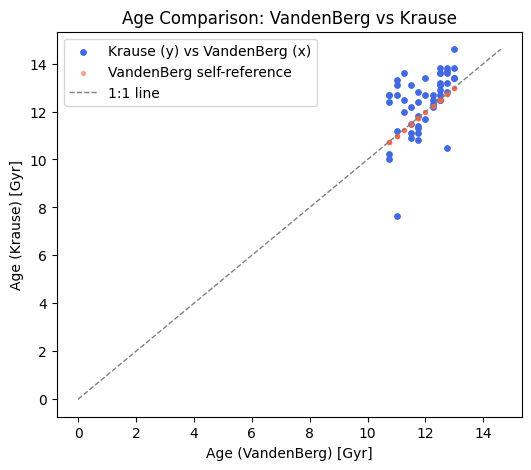

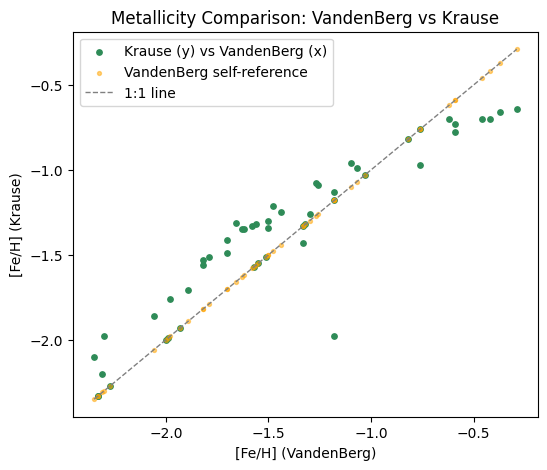

In [52]:
### Age comparison coloured
plt.figure(figsize=(6, 5))

# plot both separately for colour distinction
plt.scatter(vbk["Age_vdb"], vbk["Age_k"], s=15, color="royalblue", label="Krause (y) vs VandenBerg (x)")

# also show each dataset along axes for visual context (optional)
plt.scatter(vbk["Age_vdb"], vbk["Age_vdb"], s=8, color="tomato", alpha=0.5, label="VandenBerg self-reference")

# 1:1 guide line (perfect agreement)
max_age = max(vbk["Age_vdb"].max(), vbk["Age_k"].max())
plt.plot([0, max_age], [0, max_age], "--", color="gray", lw=1, label="1:1 line")

plt.xlabel("Age (VandenBerg) [Gyr]")
plt.ylabel("Age (Krause) [Gyr]")
plt.title("Age Comparison: VandenBerg vs Krause")
plt.legend()
plt.show()



### FeH Comparison coloured
plt.figure(figsize=(6, 5))

plt.scatter(vbk["FeH_vdb"], vbk["FeH_k"], s=15, color="seagreen", label="Krause (y) vs VandenBerg (x)")
plt.scatter(vbk["FeH_vdb"], vbk["FeH_vdb"], s=8, color="orange", alpha=0.5, label="VandenBerg self-reference")

# 1:1 line
min_feh = min(vbk["FeH_vdb"].min(), vbk["FeH_k"].min())
max_feh = max(vbk["FeH_vdb"].max(), vbk["FeH_k"].max())
plt.plot([min_feh, max_feh], [min_feh, max_feh], "--", color="gray", lw=1, label="1:1 line")

plt.xlabel("[Fe/H] (VandenBerg)")
plt.ylabel("[Fe/H] (Krause)")
plt.title("Metallicity Comparison: VandenBerg vs Krause")
plt.legend()
plt.show()




In [53]:
# the 1/1 line lets us see where the two datasets. It represents the perfect age agreement and the deviations 
# from it show systematic differences between the two.


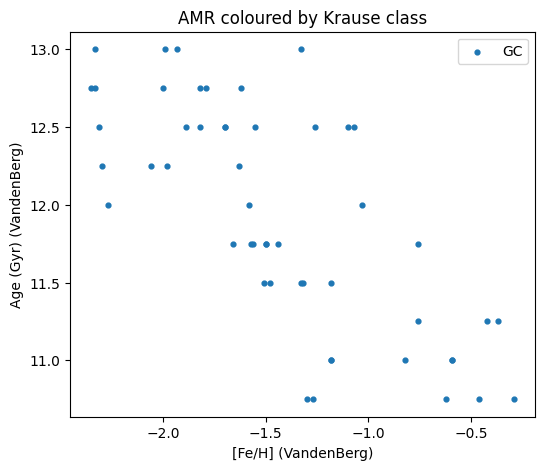

In [54]:
# find 'class' column regardless of case
cls_col = next((c for c in vbk.columns if c.lower() == "class"), None)
if cls_col is None:
    print("No 'Class' column found in vbk. Columns are:", list(vbk.columns))
else:
    ok = vbk[cls_col].notna()
    if ok.sum() == 0:
        print("All 'Class' values are NaN — nothing to color by.")
    else:
        feh = pick_col(vbk, "FeH_vdb")
        age = pick_col(vbk, "Age_vdb")
        plt.figure(figsize=(6,5))
        for c, sub in vbk.loc[ok].groupby(cls_col):
            plt.scatter(sub[feh], sub[age], s=12, label=str(c))
        plt.xlabel("[Fe/H] (VandenBerg)")
        plt.ylabel("Age (Gyr) (VandenBerg)")
        plt.title("AMR coloured by Krause class")
        plt.legend()
        plt.show()






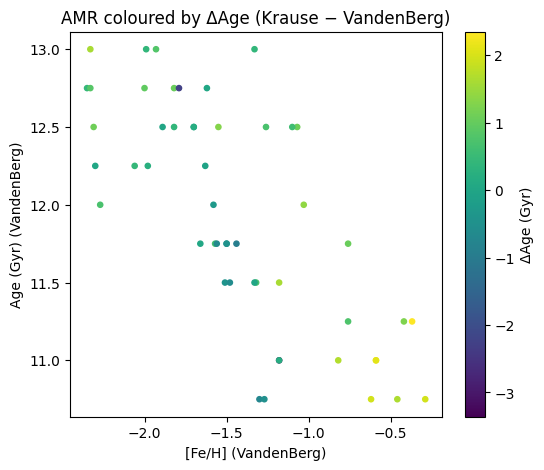

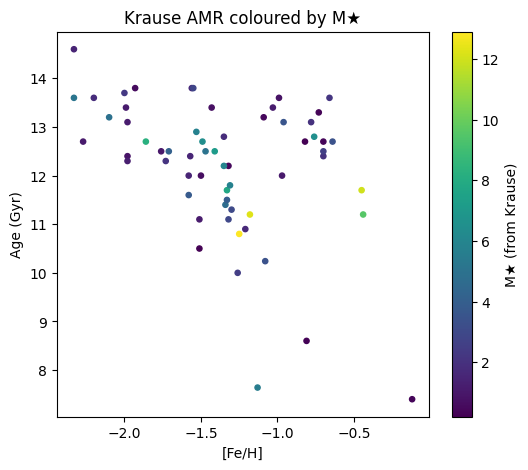

In [55]:
# colouring graphs

vbk["dAge"] = vbk["Age_k"] - vbk["Age_vdb"]
plt.figure(figsize=(6,5))
sc = plt.scatter(vbk["FeH_vdb"], vbk["Age_vdb"], s=14, c=vbk["dAge"])
plt.xlabel("[Fe/H] (VandenBerg)"); plt.ylabel("Age (Gyr) (VandenBerg)")
plt.title("AMR coloured by ΔAge (Krause − VandenBerg)")
plt.colorbar(sc, label="ΔAge (Gyr)")
plt.show()



def pick_col(df, *cands):
    cols = {c.lower(): c for c in df.columns}
    for name in cands:
        if name.lower() in cols:
            return cols[name.lower()]
    raise KeyError(f"None of {cands} found in columns: {list(df.columns)}")

feh_col = pick_col(krause, "FeH", "feh")
age_col = pick_col(krause, "Age", "age")
mstar_col = pick_col(krause, "Mstar", "mstar")

plt.figure(figsize=(6,5))
sc = plt.scatter(krause[feh_col], krause[age_col], s=14, c=krause[mstar_col])
plt.xlabel("[Fe/H]"); plt.ylabel("Age (Gyr)")
plt.title("Krause AMR coloured by M★")
plt.colorbar(sc, label="M★ (from Krause)")
plt.show()


# TODO: do spatial map, combine harris I and III, some more trends. 